In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import (
    MF,
    ItemKNN,
    UserKNN,
    NMF,
    BPR,
    LightGCN,
    SVD,
    MostPop,
    VAECF,
    NeuMF,
)
import pandas as pd
import numpy as np
import random

# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=["itemID", "Category", "userID", "Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID", "Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd

,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:
restaurants = pd.read_csv(
    "./cornac/data_c/yelp/i_id_mapping.csv",
    sep="\t",
    header=0,
    names=["item_id", "Category", "itemID"],
)
restaurants = restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
users = pd.read_csv(
    "./cornac/data_c/yelp/u_id_mapping.csv",
    sep="\t",
    header=0,
    names=["user_id", "Gender", "userID"],
)
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [8]:
# users
user_features_numpy[:, 0]

array([1, 1, 1, ..., 1, 0, 0])

In [9]:
item_features_numpy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [7]:
dataset = rating_data
unique_categories.__len__()

21

In [73]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
    fmt="UIR",
)
models = []
x = []
alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
# alpha_values = [0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        VAECF(
            k=20,
            autoencoder_structure=[60,32],
            act_fn="relu",
            likelihood="bern",
            n_epochs=50,
            batch_size=128,
            learning_rate=0.0005,
            alpha=alpha_values[i],
            top_k=50,
            beta=1,
            name=f"a={alpha_values[i]} vae",
            seed=123,
            verbose=True,
            # early_stopping=True
        )
    )


# Early stopping:
# - best epoch = 5, stopped epoch = 15
# - best monitored value = 0.062177 (delta = 0.000021)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 50/50 [00:02<00:00, 22.18it/s, loss=1.71]


[884.9312744140625, 882.5948486328125, 880.4240112304688, 878.087890625, 876.0466918945312, 874.0122680664062, 871.3710327148438, 869.6033935546875, 866.867431640625, 863.7490234375, 861.4684448242188, 861.489990234375, 857.3489990234375, 855.0188598632812, 851.5498046875, 847.2013549804688, 845.3406372070312, 841.9681396484375, 837.9872436523438, 834.635009765625, 829.8966064453125, 824.497802734375, 825.3953857421875, 819.5279541015625, 814.3600463867188, 808.9532470703125, 805.1406860351562, 799.8201904296875, 791.5916748046875, 785.3629760742188, 774.143798828125, 771.1220703125, 761.093505859375, 753.7487182617188, 743.2649536132812, 731.014404296875, 724.6583862304688, 710.3460693359375, 698.31005859375, 681.3291625976562, 671.1875610351562, 660.19873046875, 638.6788330078125, 620.4563598632812, 695.5601806640625, 594.368408203125, 577.14013671875, 553.61083984375, 531.6808471679688, 516.72412109375, 496.90484619140625, 496.86541748046875, 474.7626953125, 441.94061279296875, 415.

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 1874.79it/s]



[a=0.1 vae] Training started!


...


[a=0.6 vae] Training started!


100%|██████████| 50/50 [01:16<00:00,  1.54s/it, loss=1.86]


[614.30712890625, 612.7499389648438, 610.6943359375, 609.725830078125, 608.293212890625, 607.0921630859375, 605.4237670898438, 604.73828125, 603.3754272460938, 601.8607177734375, 599.8858032226562, 603.53271484375, 599.2548828125, 597.3784790039062, 596.4869995117188, 593.8378295898438, 593.0239868164062, 591.5560302734375, 589.0692138671875, 588.240966796875, 586.3759155273438, 584.0709228515625, 590.1101684570312, 582.2005615234375, 580.4605102539062, 578.6188354492188, 576.0140380859375, 574.0640869140625, 569.2826538085938, 568.9132080078125, 562.4843139648438, 564.3056030273438, 556.9833984375, 567.2950439453125, 553.4058837890625, 549.7520141601562, 548.8593139648438, 542.5228881835938, 541.9181518554688, 533.5390014648438, 532.2499389648438, 530.4819946289062, 518.294189453125, 511.4137878417969, 559.0136108398438, 508.1417236328125, 505.3390808105469, 493.8031311035156, 486.6021728515625, 484.063720703125, 482.5897216796875, 483.53228759765625, 469.5914001464844, 456.6835327148

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 1832.05it/s]


VALIDATION:
...
          |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
--------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 vae   | 0.6396 | 0.0343 |      0.6094 | 0.0328 | 0.1128 |  0.0765 |       0.0207 |    0.1324 |   0.7033
a=0.1 vae | 0.6384 | 0.0341 |      0.6079 | 0.0325 | 0.1119 |  0.0758 |       0.0205 |    0.1311 |   0.7226
a=0.2 vae | 0.6343 | 0.0335 |      0.6094 | 0.0321 | 0.1119 |  0.0747 |       0.0201 |    0.1288 |   0.7053
a=0.3 vae | 0.6282 | 0.0334 |      0.6049 | 0.0315 | 0.1105 |  0.0738 |       0.0202 |    0.1278 |   0.7042
a=0.4 vae | 0.6229 | 0.0328 |      0.5965 | 0.0307 | 0.1084 |  0.0720 |       0.0198 |    0.1248 |   0.7284
a=0.5 vae | 0.6152 | 0.0310 |      0.5616 | 0.0293 | 0.1061 |  0.0679 |       0.0187 |    0.1169 |   0.7736
a=0.6 vae | 0.6109 | 0.0301 |      0.5540 | 0.0275 | 0.0972 |  0.0646 |       0.0182 |    0.1135 |   0.7201

TEST:
...


In [74]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [89]:
# models[0].save("./saved")
import pickle

with open("yelp100k.pkl", "wb") as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)

In [87]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [88]:
np.save("reco_matrix_vae_yelp_100k.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_vae_yelp_100k.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [78]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)

In [79]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
import math
restaurants_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
restaurants_df = restaurants_df[unique_categories].sum()
new_top_k = math.floor(restaurants_df.max())

print(restaurants_df)
# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


# grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

Active Life & Fitness           11.809524
Arts & Entertainment            66.785714
Automotive                       4.119048
Bars & Nightlife               132.900000
Coffee,Tea & Desserts           77.876190
Drinks & Spirits                18.316667
Education & Learning             0.642857
Event Services                  38.342857
Family & Kids                    1.000000
Food & Restaurants             686.188095
Health & Beauty                  9.235714
Home & Garden                    1.533333
Miscellaneous                    4.719048
Outdoor Activities               5.652381
Public Services & Community      6.792857
Shopping & Fashion              25.811905
Specialty Food & Groceries      22.895238
Sports & Recreation              6.183333
Technology & Electronics         1.869048
Travel & Transportation         24.342857
Asian                          124.983333
dtype: float64


In [80]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [81]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


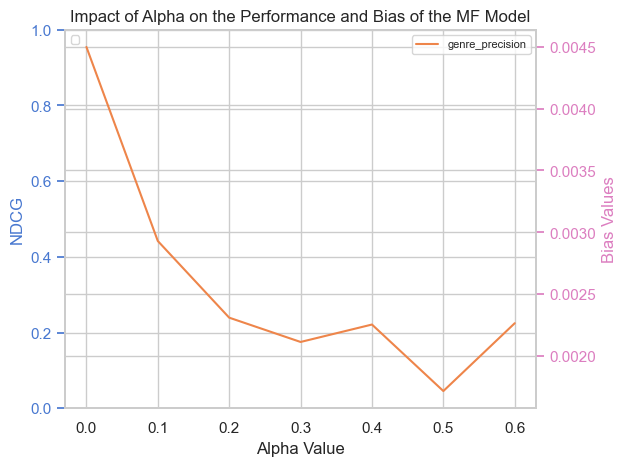

In [83]:

import matplotlib.pyplot as plt
import seaborn as sns
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]

x = alpha_values
upper_bound = 7

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()
#
# ax1.plot(x, ndcg_list, linestyle="--", color=pastel_palette[0], label="NDCG")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("NDCG", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x, gp_sum, label=titles[0], color=pastel_palette[1])
# ax2.plot(x, gm_sum, label=titles[2], color=pastel_palette[3])
# ax2.plot(x, gdcg_sum, label=titles[3], color=pastel_palette[4])
# ax2.plot(x, gmrr_sum, label=titles[4], color=pastel_palette[5])
# ax2.plot(x, grp_sum, label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1) 
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.show()
#  VAECF(
#             k=20,
#             autoencoder_structure=[64,32],
#             act_fn="relu",
#             likelihood="bern",
#             n_epochs=50,
#             batch_size=128,
#             learning_rate=0.0005,
#             alpha=alpha_values[i],
#             top_k=50,
#             beta=1,
#             name=f"a={alpha_values[i]} vae",
#             seed=123,
#             verbose=True,
#             # early_stopping=True
#         )
 
    

In [85]:
gp_sum

[0.00449871803300241,
 0.002930116363158218,
 0.0023102798413428727,
 0.002113821138211347,
 0.0022547279381149787,
 0.0017170687879385794,
 0.0022654657813424616]

In [ ]:
|